In [103]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from arch import arch_model

In [104]:
def get_data(ticker="AAPL", lookback_days=1000):
    df = yf.download(
        ticker,
        period=f"{lookback_days}d",
        auto_adjust=True,
        progress=False
    )
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    df.dropna(inplace=True)
    return df
df = get_data("AAPL")
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-03-29,175.342224,175.391201,172.775179,173.118109,100589400
2022-03-30,174.176300,175.979100,173.127923,174.940531,92633200
2022-03-31,171.080170,174.431031,170.874408,174.244869,103049300
2022-04-01,170.786255,171.344739,168.464170,170.511916,78751300
2022-04-04,174.832764,174.881756,170.913625,171.041002,76468400


In [105]:
def add_garch_feature(df: pd.DataFrame):
    df = df.copy()

    returns = df["log_return"] * 100
    returns = returns.dropna()

    garch = arch_model(returns, vol='Garch', p=1, q=1)
    res = garch.fit(disp="off")
    
    garch_vol = res.conditional_volatility

    df["garch_vol"] = np.nan
    df.loc[garch_vol.index, "garch_vol"] = garch_vol.values

    df["garch_vol"] = df["garch_vol"].shift(1)

    return df

In [106]:
def compute_features(df: pd.DataFrame, price_col: str = "Close") -> pd.DataFrame:
    """
        From price series compute engineered features from OHLCV data.
    """

    df = df.copy()

    df["log_return"] = np.log(df[price_col] / df[price_col].shift(1))

    df["log_volume_change"] = np.log((df["Volume"] + 1) / (df["Volume"].shift(1) + 1)) # avoiding log 0 issues

    df["log_trading_range"] = np.log(df["High"]/df["Low"])
    df["close_open_return"] = np.log(df["Close"]/df["Open"])

    # Volatility features
    trading_days = 252
    df["realized_vol_5d"] = df["log_return"].rolling(5).std() * np.sqrt(trading_days)
    df["realized_vol_21d"] = df["log_return"].rolling(21).std() * np.sqrt(trading_days)
    df["realized_vol_63d"] = df["log_return"].rolling(63).std() * np.sqrt(trading_days)

    # Momentum Features
    df["ma_5"] = df["Close"].rolling(5).mean()
    df["ma_21"] = df["Close"].rolling(21).mean()
    df["ma_ratio"] = df["ma_5"] / df["ma_21"] #trend signal

    df["vol_change"] = df["realized_vol_21d"].pct_change()

    df = add_garch_feature(df)
    df["garch_vol"] = df["garch_vol"]

    print(f"DataFrame length: {len(df)}")
    print(f"NaN counts:\n{df.isna().sum()}")
    print(f"Rows with ALL values present: {df.dropna().shape[0]}")
    
    df.dropna(inplace=True)

    

    return df

In [107]:
df_features = compute_features(df)

print("Shape:", df_features.shape)
df_features.head()

DataFrame length: 1000
NaN counts:
Price
Close                 0
High                  0
Low                   0
Open                  0
Volume                0
log_return            1
log_volume_change     1
log_trading_range     0
close_open_return     0
realized_vol_5d       5
realized_vol_21d     21
realized_vol_63d     63
ma_5                  4
ma_21                20
ma_ratio             20
vol_change           22
garch_vol             2
dtype: int64
Rows with ALL values present: 937
Shape: (937, 17)


Price,Close,High,Low,Open,Volume,log_return,log_volume_change,log_trading_range,close_open_return,realized_vol_5d,realized_vol_21d,realized_vol_63d,ma_5,ma_21,ma_ratio,vol_change,garch_vol
Date,,,,,,,,,,,,,,,,,
2022-06-29,136.615814,138.028779,134.103883,134.879058,66242400,0.012940,-0.012616,0.028847,0.012794,0.351802,0.385041,0.405298,137.029910,137.740037,0.994844,-0.061026,2.222160
2022-06-30,134.152954,135.771968,131.258346,134.673002,98964500,-0.018192,0.401440,0.033809,-0.003869,0.352670,0.388401,0.406265,136.725723,137.173731,0.996734,0.008727,2.280378
2022-07-01,136.321472,136.429407,133.112880,133.485735,71051600,0.016035,-0.331355,0.024610,0.021021,0.316931,0.394509,0.407258,136.189978,136.716761,0.996147,0.015726,2.205095
2022-07-05,138.902084,138.951149,134.359012,135.183252,73353800,0.018753,0.031888,0.033607,0.027138,0.356885,0.395896,0.409694,136.170355,136.265864,0.999299,0.003517,2.169923
2022-07-06,140.236526,141.413992,138.431078,138.696013,74064300,0.009561,0.009639,0.021319,0.011046,0.237177,0.375289,0.406952,137.245770,136.150918,1.008041,-0.052054,2.117127


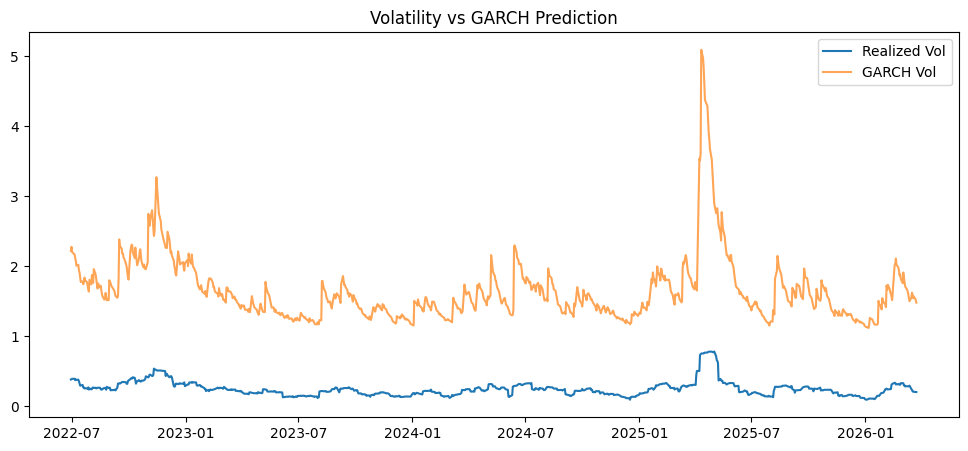

In [108]:
plt.figure(figsize=(12,5))
plt.plot(df_features["realized_vol_21d"], label="Realized Vol")
plt.plot(df_features["garch_vol"], label="GARCH Vol", alpha=0.7)
plt.legend()
plt.title("Volatility vs GARCH Prediction")
plt.show()